In [2]:
try:
    import pytorch
except ImportError:
    !pip3 install torch torchvision
    #pip3 install --pre torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/nightly/cpu
    pass

try:
    from torchsummary import summary
except ImportError:
    !pip3 install torchsummary
    pass

import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

#import ml_utils

# Neural Networks and Images

Images are perhaps the place where neural networks have had the most dramatic impact. The best neural networks can very accurately perform image recognition, to the point that they can identify disease in medical imaging better than doctors, or track people's faces (or even their gait) in real time video. 

Image processing and applications such as image recognition is one of the most visible and exciting applications of neural networks. In contrast to our previous models that can perform image classification, the structure of neural networks allows them to be tailored to be very good at dealing with image data. This also tends to be true for many "analog" data types, such as audio, video, and text, which is why many of the most impressive current applications of AI, like live translation and facial recognition, use neural networks. 

### GPU Acceleration Check

Before we start actually training models, we want to make sure that we use GPU acceleration if it's available. The code snippet below checks if a GPU is available and sets the device accordingly. If a GPU is not available, it defaults to using the CPU.

In [ ]:
BATCH_SIZE = 128
TEST_SPLIT = 0.1
VAL_SPLIT = 0.15
EPOCHS = 3
USE_WEIGHTS = False
LEARN_RATE = 0.001
OUTPUT_CLASSES = 10
HIDDEN_UNITS = 512
DIM_X = 32
DIM_Y = 32
CHANNELS = 3
PIN_MEMORY = False

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA device found.", torch.cuda.is_available())
    BATCH_SIZE = 1024
    EPOCHS = 12
    PIN_MEMORY = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print ("MPS device found.", torch.backends.mps.is_available())
    BATCH_SIZE = 512
    EPOCHS = 6
else:
    device = torch.device("cpu")
    print ("MPS/GPU device not found.")
    BATCH_SIZE = 1024
    EPOCHS = 3

CUDA device found. True


## Image Data

Until now we've used simple images that only have one color, we can expand this a bit now to handle more "normal" images. We will use one of the sample ones from Keras called cifar10. 

### Color Images

Color images have a greater depth - one layer for each color. Usually this is one for red, blue, and green, or RGB. There are other color encodings, but the idea is pretty similar. Of note for us, these images are now 3 dimensional - in terms of their representation as an array. 

![RGB](images/rgb.png "RGB" )

We will use the CIFAR-10 dataset, which consists of 60,000 32x32 color images in 10 different classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck). The dataset is divided into 50,000 training images and 10,000 test images. This dataset is built into PyTorch's torchvision library, and that allows us to download the data in dataset format. 

The normalization step here uses mean and standard deviation values that are commonly used for the CIFAR-10 dataset, someone precalculated these and I just copied them here. To get the 'true' values for your own dataset, you would need to calculate the mean and standard deviation of your dataset's pixel values and use those. That requires loading the dataset (or a large sample of it) and therefore can't be done in-line with loading the dataset as we did here. 

### Compose

The `transforms.Compose` function is used to chain together multiple transformations that will be applied to the images in the dataset. In this case, we are applying two transformations:
1. `transforms.ToTensor()`: This converts the images from their original format (PIL images or NumPy arrays) into PyTorch tensors, which are the data structure used for training models in PyTorch.
2. `transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))`: This normalizes the pixel values of the images using the specified mean and standard deviation for each color channel (this I got from the internet, as this dataset is commonly used and these values are well-known). In general, we can calculate the mean and standard deviation of our dataset and use those values here to normalize our images.

#### Train-Test Split

Most of the datasets that we can load directly have some kind of pre-defined train-test split in the data, usually triggered by a parameter such as in the example below. If your dataset doesn't have a pre-defined train-test split, such as a custom dataset, the PyTorch equivalent of `train_test_split` is `torch.utils.data.random_split`, which allows you to split a dataset into random train and test subsets. This may also be useful if we have a train-test split initially, but need to add a validation set, which is common when training neural networks. 

<b>Note:</b> It is technically correct to have train, test, and validation sets as we saw when we looked at cross-validation. If we want to publish our results and claim our Nobel Prize, we want to do things the correct way. In practice, we often just use the test set as a validation set and ignore a post-training test set. There are a couple of reasons why this is sort of OK, and commonly done:
<ul>
<li> Train-test splits can be expensive, so doing sklearn style cross-validation is often not feasible with neural networks. </li>
<li> As a dataset grows larger, the difference between different validation splits will get smaller. </li>
</ul>

So, we normally won't get different results with our lazy version than we would with a more careful version, and the lazy version is much easier to implement.

In [4]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data = datasets.CIFAR10('data', 
                              train=True,
                              download=True,
                              transform=train_transform
                              )
test_data = datasets.CIFAR10('data',
                             train=False,
                             download=True,
                             transform=test_transform
                             )

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s] 


### Image Shapes and Color

One of our images has the dimensions 32x32x3. This means that it is 32 pixels wide, 32 pixels tall, and has 3 layers of color - red, green, and blue. Each image is effectively the 3 color layers stacked on top of each other to generate a full color image.

There are other ways to encode image data, or different color spaces. RGB is probably the most common, but other ones exist and may perform better in certain scenarios. The concept is the same, but the color data is broken up into different components other than red, green, and blue. For example, a lot of image processing is done in YCbCr, which is a color space that tends to be more efficient for image processing. We won't go into the details of different color encodings, if we need to deal with images that are defined in that color space, we can use a library to convert them to RGB.

#### Image Preview

Since our data is in a dataset, we can create a preview function to visualize some of the images along with their labels. There is a parameter in the function to unnormalize the images for better visualization. The normalized images are better for predictive models, but not so nice for human eyeballs. 

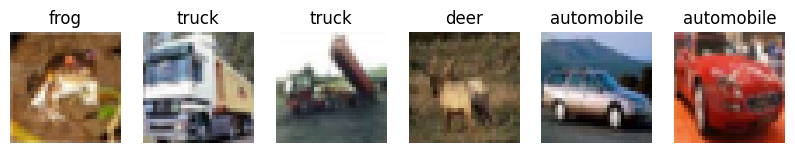

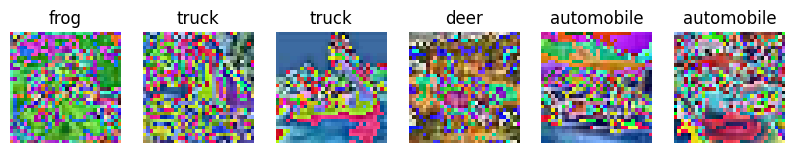

In [5]:
def image_preview(data, num_images=4, dimensions=(DIM_X, DIM_Y), color_depth=CHANNELS, class_labels=None, unnormalize=False):
    fig, axes = plt.subplots(1, num_images, figsize=(10, 5))
    for i in range(num_images):
        img, label = data[i]
        if unnormalize:
            img = img.clone()
            for c in range(color_depth):
                img[c] = img[c] * 0.229 + 0.485 if c == 0 else img[c] * 0.224 + 0.456 if c == 1 else img[c] * 0.225 + 0.406
        img = transforms.ToPILImage()(img)
        if np.max(np.asarray(img)) > 1:
            axes[i].imshow(np.asarray(img))
        else:
            axes[i].imshow(np.asarray(img)*255)
        axes[i].axis('off')
        if class_labels:
            axes[i].set_title(class_labels[label])
    plt.show()

image_preview(train_data, num_images=6, dimensions=(DIM_X, DIM_Y), class_labels=train_data.classes, unnormalize=True)
image_preview(train_data, num_images=6, dimensions=(DIM_X, DIM_Y), class_labels=train_data.classes, unnormalize=False)

### Data Shape and Model

Our data starts as images that are 32 x 32 x 3 - 32 pixels by 32 pixels by color depth of 3 (RGB).

#### Flatten

One new addition we can utilize is the Flatten layer, which does exactly what is says.  The flatten layer does the same thing we did when reshaping digit images, it makes them into a flat array. We specify the shape of one example of our dataset as the input shape argument. 

### Classification - Output Activation and Loss

Since we are doing a classification, we need to make sure the model is configured to do that. When performing a categorical classification, there must be a match between the output of the final layer and what the loss function expects. In this case, since we are using `nn.CrossEntropyLoss`, the final layer should output raw scores (logits) without a softmax activation, and the target labels should be provided as class indices (not one-hot encoded). If you were to use `nn.NLLLoss`, then you would need to apply a log-softmax activation to the final layer's output and provide one-hot encoded target labels. 

In theory, it doesn't matter which one we use, I've seen several things noting that the nn.crossentropyloss is less likely to run into exploding/vanishing gradients due to some small implementation details, so I'll default to that. 

<b>Note:</b> this is an easy place to get errors, since things will generally work if you make a mistake, just poorly. 

In [6]:
class neural_network(nn.Module):
    def __init__(self):
        super(neural_network, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(in_features=32*32*3, out_features=HIDDEN_UNITS),
            nn.ReLU(),
            nn.Linear(HIDDEN_UNITS, HIDDEN_UNITS),
            nn.ReLU(),
            nn.Linear(HIDDEN_UNITS, HIDDEN_UNITS),
            nn.ReLU(),
            nn.Linear(HIDDEN_UNITS, OUTPUT_CLASSES),
        )
        
    def forward(self, x):
        x = self.flatten(x)
        output = self.linear_relu_stack(x)
        return output
    
model = neural_network()
model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARN_RATE)

print(model)

neural_network(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=10, bias=True)
  )
)


### Training Loops

The training loop setup here has two portions - one function to do a training loop, another to accumulate results. 

#### Gradient Tracking

In the training loop, one thing that we need to manage is if we are tracking gradients or not - basically, if the algorithm is learning or not. In the example here, we can see:
<ul>
<li> Training - use `torch.set_grad_enabled(True)` </li>
<li> Validation - use `torch.set_grad_enabled(False)` or with `torch.no_grad()` </li>
</ul>

This basically tells PyTorch whether to keep track of gradient calculations to build the computation graph for backpropagation. During training, we want to track gradients so that we can update the model's parameters. During validation or testing, we don't need to track gradients since we're not updating the model, and this can save memory and computational resources.

In [7]:
def train_loop(dataloader, model, loss_fn, optimizer, epochs, val_dataloader=None):
    model.to(device)
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        with torch.set_grad_enabled(True):
            for sample, labels in dataloader:
                sample, labels = sample.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(sample)
                loss = loss_fn(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * sample.size(0)
            epoch_loss = running_loss / len(dataloader.dataset)
        #print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {epoch_loss:.4f}")
        if val_dataloader:
            with torch.set_grad_enabled(False):
                model.eval()
                val_loss = 0.0
                correct = 0
                size = 0
                with torch.no_grad():
                    for val_samples, val_labels in val_dataloader:
                        val_samples, val_labels = val_samples.to(device), val_labels.to(device)
                        val_outputs = model(val_samples)
                        v_loss = loss_fn(val_outputs, val_labels)
                        val_loss += v_loss.item() * val_samples.size(0)
                        _, predicted = torch.max(val_outputs, 1)
                        correct += (predicted == val_labels).sum().item()
                        size += val_labels.size(0)
                val_epoch_loss = val_loss / len(val_dataloader.dataset)
                print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {epoch_loss:.4f}, Validation Loss: {val_epoch_loss:.4f}, Val Accuracy: {100 * correct / size:.2f}%")

def process_loop(dataloader, model, loss_fn, optimizer, epochs, mode='train'):
    model.to(device)
    if mode == 'train':
        model.train()
    else:
        model.eval()
    running_loss = 0.0
    correct = 0
    size = 0
    with torch.no_grad():
        for sample, labels in dataloader:
            sample, labels = sample.to(device), labels.to(device)
            outputs = model(sample)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item() * sample.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            size += labels.size(0)
    epoch_loss = running_loss / len(dataloader.dataset)
    accuracy = 100 * correct / size
    print(f"{mode.capitalize()} Loss: {epoch_loss:.4f}, {mode.capitalize()} Accuracy: {accuracy:.2f}%")
    return epoch_loss, accuracy

def full_train_loop(train_dataloader, val_dataloader, model, loss_fn, optimizer, epochs):
    for epoch in range(epochs):
        print(f"Epoch [{epoch+1}/{epochs}]")
        process_loop(train_dataloader, model, loss_fn, optimizer, epochs, mode='train')
        process_loop(val_dataloader, model, loss_fn, optimizer, epochs, mode='val')

def multiDatasetTestRun(model, dataloaders=[]):
    model.to(device)
    model.eval()
    preds_and_labels = []
    with torch.no_grad():
        for dataloader in dataloaders:
            for sample, labels in dataloader:
                sample, labels = sample.to(device), labels.to(device)
                outputs = model(sample)
                _, predicted = torch.max(outputs, 1)
                preds_and_labels.append((predicted.cpu(), labels.cpu()))
    return preds_and_labels

In [8]:
train_loop(train_loader, model, loss_fn, optimizer, epochs=EPOCHS, val_dataloader=test_loader)
full_res = multiDatasetTestRun(model, dataloaders=[test_loader, train_loader])

Epoch [1/12], Training Loss: 1.7353, Validation Loss: 1.5336, Val Accuracy: 45.68%
Epoch [2/12], Training Loss: 1.4592, Validation Loss: 1.4141, Val Accuracy: 49.88%
Epoch [3/12], Training Loss: 1.3288, Validation Loss: 1.3642, Val Accuracy: 51.70%
Epoch [4/12], Training Loss: 1.2241, Validation Loss: 1.3644, Val Accuracy: 52.20%
Epoch [5/12], Training Loss: 1.1262, Validation Loss: 1.3117, Val Accuracy: 54.04%
Epoch [6/12], Training Loss: 1.0348, Validation Loss: 1.3191, Val Accuracy: 54.22%
Epoch [7/12], Training Loss: 0.9413, Validation Loss: 1.3482, Val Accuracy: 54.30%
Epoch [8/12], Training Loss: 0.8597, Validation Loss: 1.3618, Val Accuracy: 55.22%
Epoch [9/12], Training Loss: 0.7567, Validation Loss: 1.4397, Val Accuracy: 54.11%
Epoch [10/12], Training Loss: 0.6858, Validation Loss: 1.4832, Val Accuracy: 54.06%
Epoch [11/12], Training Loss: 0.6080, Validation Loss: 1.5706, Val Accuracy: 54.40%
Epoch [12/12], Training Loss: 0.5218, Validation Loss: 1.6542, Val Accuracy: 54.70%


## CNNs - Convolutional Neural Networks

To deal with images a little bit better we can use a different kind of neural network design - a CNN, or convolutional neural network. In short, a CNN is able to look at an image "as it is" capturing spatial relationships that processing an image as a flattened array do not. When using a CNN we can first process the image in its original dimensions in the initial layers of the network, then flatten it down to go through a more familiar set of layers for the final prediction. 

A CNN looks at an image bit by bit, looking at a small square, then sliding over a few pixels, looking at another square, and so on. This has the effect of being able to extract features from areas of an image - as an example, think of an image of a bike, a CNN would be able to identify the distinct shape of a seat or handle bars as the image passes through the layers. This improves the ability of the model to identify patterns of data that define shapes in images, no matter where in the image that shape is.

### CNN Structure

A CNN has some new types of layers:
<ul>
<li> Convolutional layer - the convolutional layer looks at a small frame of the image at a time.
<li> Pooling layer - the pooling layer reduced the dimensionality of the data. 
<li> Regular neural network - after the convolutional parts to their work, we can flatten the data and pass it to a regular fully connected network at the final layers. 
</ul>

### Convolutional Layer

##### Simple Image

![CNN](images/cnn.gif "CNN")

##### More Complex Image

The convolutional layer is easiest to think of as a microscope that scrolls over an image looking at one small square of it at a time. This image is the most illustrative animation I found of showing the convolution process; note that this one shows a stride of 2, which is why the filter seems to jump and is why the size of the output is so much smaller. We will normally rely on the pooling layer to reduce size, and use a stride of 1 with same padding to keep our outputs the same size as the inputs.  

![Kernel](images/cnn_kernel.gif "Kernel" )


This convolution operation translates the input "feature map" into an "output map". After the transformation the result is that each layer captures some features in the image - edges, orientation, etc... and map those down to lower layers. 

### Filters (a.k.a kernel) in the Convolutional Layer

One of the arguments we provide when making a convolutional layer is the number of filters. We have a whole bunch of filters, each learns to find some different characteristic from the image data as the training progresses. Another argument is the size of the filter. In general, filter sizes are small squares such as 3 by 3 or 5 by 5, but as images become massively higher in resolution and computers become faster, larger filters are becoming more widespread and the typical size will likely continue to increase to some degree. 

The actual values in the kernel are learned during training in a CNN, like most other things, they are determined throughout the backpropagation steps in the gradient descent process. In the context that we are typically using, image classification, the weights in the filters are learned to minimize the loss. In other words, the filters are learning to find the features that are most important to the model in order to make the best predictions. Or if we phrase it in a less nerdy way, the filters are trained to identify the parts of the image that allow it to be classified. This part is somewhat like magic, the model learns how to differentiate the different images, and it learns how to make filters that extract the key things needed to do so. 

### Padding

Padding is a setting that determines if the dimensionality of the data is reduced in the convolutional layer or not. We have the option to add padding with the padding parameter in a convolutional layer. 

This is probably most easily illustrated by looking at the image above. That image is showing padding of 1 - those 0s around the border are inserted to ensure that the kernel can start at the edge and still capture the entire picture. If this were 0 padding the kernel would start at the real edge, and those edge values would never make it to the middle of the image. The resulting values will then be of a smaller dimension than the original. Using same padding allows the model to better capture the information around the border, avoiding what is known as the border effect. 

In general, we should expect fractionally better performance with padding enabled, at the cost of some processing time and memory. This effect isn't usually massive, as with most pictures the valuable stuff is in the middle - so the impact depends on the dataset. If you think of the minst images or something like a passport photo, the edges are usually pretty unimportant. If you think of a picture captured by a self-driving car, the edges may be the most important, to see things like curbs and kids jumping in front of the car.

#### Strides

The stride value is how many pixels the kernel window shifts each time it looks at a window. Strides of 1 move 1 pixel at a time, larger strides "skip" some pixels. Our stride will usually just be 1. 

### Pooling Layer

The pooling layer reduces the dimensionality of the data down. In image terms that you may have heard elsewhere we are downsampling - taking something that is at some higher resolution and transforming it to a lower resolution. 

This pooling step reduces the size of the data, making for more efficient calculations. It also helps generalize the ability of the model to recognize certain features. We can capture this generalization by thinking of an example - higher vs lower definition images. If we have a high definition image of something it is extremely clear, and if we have similar objects it is easy to tell them apart. For example if there are multiple cars in an image, we can probably tell them apart pretty easily - the details show the differences. If the cars are in the background of an image (if they are in the background we are only getting a low definition version of those cars) it is harder to tell them apart - the details are different, but the general "characteristic", the fact it is a car, is consistent. Our pooling has the same impact - the pooling changes the higher definition images to lower ones, and we are better able to identify those general characteristics - making it easier to spot things that are "the same" in other images. 

The default pooling window is 2x2, so 4 features are collapsed into one. 

#### Max and Average Pooling

There are two common pooling strategies - max and average. Max pooling takes the maximum value in the pooling window as the output, average takes the average of the values in the pooling window.
<ul>
<li> Max is more common, it tends to do a better job at finding contrast - differences between light and dark, which is helpful in doing things like separating foreground and background or doing edge detection (think of navigation).
<li>Average tends to capture a more broad set of information on the entire image, with less focus on areas of distinct difference. 
</ul>

![Max_Average_Pooling](images/max_avg_pool.png "Max_Average_Pooling" )

### Normal Neural Network Layers

Once the above work is done, potentially with several layers of layers, the final layers in the network are a normal neural network. The CNN parts act to extract features from the image, the final layers take those features and produce a prediction, just as we are used to. So, loosely, the CNN classification model does some image processing in the convolutional layers to extract features and patterns from the image, we then feed the information extracted from the images into a 'normal' neural network model that makes a prediction from some features. 

### Overall Structure

After the entire model is constructed we end up with something like this. The image is translated into a series of representations - one per layer, through the convolutional process. The pooling then lowers the dimensions of those representations, and the process (potentially repeats). At the end of all the convolutional steps we feed our final representations into the dense stages - these features are in the "shape" of an image - with the details being totally different - each layer is a filter (rather than a color) and the dimensions of the "image" are determined by the amount of pooling and padding. This is all flattened and the dense part goes on as we are used to in making predictions. 

![CNN Structure](images/cnn_structure.jpg "CNN Structure" )


### CNN Model Architecture

Convolutional neural networks have two major components: the convolutional layers and the fully connected layers. The convolutional layers are responsible for feature extraction, while the fully connected layers are responsible for making predictions based on those features.

#### Feature Construction

The top, convolutional layers, of the model serve to construct features from the raw data that are then passed to the fully connected layers (often called the classifier) to make predictions. The convolutional layers are, hopefully at least, better at extracting useful features from the images than using the raw pixel values as features in a fully connected model. The CNN layers generate features by looking for local patterns in the images, such as edges, textures, and shapes - this allows the model to construct features that capture the spatial relationships between pixels, which is crucial for understanding the content of the images.

#### Fully Connected Layers

After the data is processed through the convolutional layers, it is flattened and passed to the fully connected layers. The output of the convolutional layers is effectively the set of features that the model has constructed from the raw data, once we hit the fully connected layers, we're just using those features to make predictions like any other model. 

#### Backpropagation and Training Kernels

As the model is trained, all the weights in all of the layers are updated through gradient descent to lower the amount of loss, including both the convolutional layers and the fully connected layers. We can picture the FC layers as 'instructing' the convolutional layers on which features it needs to make accurate predictions, and the convolutional layers adjusting themselves to provide that. As the loss is attributed to individual terms during backpropagation, each layer basically gets told, "these features you constructed are helpful, and these other ones are bad", and that changes the weights in each kernel to 'train' them to detect useful stuff. 

For example, if a model is controlling a self-driving car, detecting edges might be very good to stay in the lane. Over time, some kernels will learn to detect edges as that'll lead to lower loss, so it is incentivized. Since the parts of the model that generate the 'edges' features are helpful (i.e. they don't introduce loss), these edge detecting kernels will be reinforced and become better. Each kernel will have a similar thing happen - it detects something, if that thing is useful for the model, it'll be kept and refined; if that thing is not useful, the loss will be large, and it will be adjusted to try to detect something else. Importantly, whatever is important to the loss is what is ultimately detected by the kernels. 

#### Extracting Images

Each of the "get" functions below isn't needed for creating a model, I added them to help us extract some example images to let us visualize what is happening to the data as it is passed through the convolutional steps. 

### Simple CNN

We can build a simple CNN to make some predictions on our images. In our network we'll have:
<ul>
<li> Convolutional portion:
    <ul>
    <li> Convolutional layer - 32 filters, relu activation, same padding. 
    <li> Pooling layer - (2, 2) size. Results in data 1/4 of original size.
    </ul>
<li> Dense portion:
    <ul>
    <li> Flattening of the convolutional results. 
    <li> Dense layer. 
    <li> Output layer, 10 classes, softmax prediction. 
    </ul>
</ul>

<b>Note:</b> for all the models below, I didn't really optimize them much, if at all. I just wanted to show the general structure of the models and observe the results. In general, the visualization of the images through the layers becomes a little more 'clear' as the models become better trained. If we were doing this for real, we'd spend more time optimizing the structure that worked well. For this example, we'd probably do something like:
<ul>
<li> For whatever general model structure performed well, adjust around that - add/remove a layer, add/remove some neurons, etc... </li>
<li> Try some variations on the convolutional layers - different filter sizes, different numbers of filters, etc... </li>
<li> Allow for the model to train more, most of these seemed to be generally improving when they stopped. I stopped them for practical reasons. </li>
<li> Adjust the regularization options to contain overfitting. Try a few different combinations. </li>
<li> Other stuff like another layer in the dense portion, etc... </li>
</ul>

This can take a while. We do have some grid-search like options in Keras, those are documented in the Keras Tuner section. Neural networks are very flexible in how they learn, so different models can converge on a similar solution.

#### Fully Connected Size

One thing we do need to be attentive to is the size of the data coming out of the convolutional layers. In CNNs, the data gets smaller in terms of height and width as it goes through the convolutional layers, in most cases that is partnered with the number of channels increasing, so the data gets "deeper" but "narrower". We need to make sure that the first layer of the fully connected portion is the right size to take in the output of the convolutional layers. If we have a mismatch, we'll get an error when we try to train the model.

The size is impacted by the pooling, padding, and stride settings in the convolutional layers, so it can vary. The easiest structure to manage is one that has both a stride and padding of 1, and a pooling size of (2, 2). This will result in the convolutional layers not changing the feature size, and the pooling dividing each dimension by 2. At the end of the convolutional layers, you can then divide each dimension by 2 for each pooling layer, and multiply by the number of filters in the final layer to get the size of the data coming out of the convolutional layers, which is the size of the input for the first layer of the fully connected portion.


In [9]:
# CNN Model
class cnn_network(nn.Module):
    def __init__(self, sample_image,kern_size=(3,3), num_kerns_1=64, num_kerns_2=128, pad_size=1, stride_size=1):
        super(cnn_network, self).__init__()
        self.sample_image = sample_image.to(device)
        self.conv1 = nn.Conv2d(in_channels=CHANNELS, out_channels=num_kerns_1, kernel_size=kern_size, padding=pad_size)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=(2,2))
        #self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=num_kerns_1, out_channels=num_kerns_2, kernel_size=kern_size, padding=pad_size)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=(2,2))
        #self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(8*8*num_kerns_2, HIDDEN_UNITS)  # Adjust the input size based on your image dimensions
        self.fc2 = nn.Linear(HIDDEN_UNITS, OUTPUT_CLASSES)


    def forward(self, x):
        x = self.conv1(x)
        
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        return x
    
    def getTransformedImagesByLayer(self):
        transformed_images = {}
        transformed_images['input'] = self.sample_image
        with torch.no_grad(): 
            x = self.sample_image.unsqueeze(0)  # Add batch dimension
            x = self.conv1(x)
            x = self.pool1(x)
            transformed_images['conv1'] = x.squeeze(0)  # Remove batch dimension
            x = self.relu1(x)
            x = self.conv2(x)
            x = self.pool2(x)
            transformed_images['conv2'] = x.squeeze(0)  # Remove batch dimension
            return transformed_images
    
    def getConvLayerKernels(self):
        layers = {}
        for i, layer in enumerate([self.conv1, self.conv2], start=1):
            layers[f'conv{i}'] = layer.weight.data
        return layers
    
    def getSalienceMaps(self, sal_image=None):
        self.eval()
        if sal_image is not None:
            input_image = sal_image.unsqueeze(0).to(device)
        else:
            input_image = self.sample_image.unsqueeze(0).to(device)
  
        input_image.requires_grad_()
        prediction = self.forward(input_image)
        score, ind = torch.max(prediction, dim=1)
        score.backward()
        saliency, _ = torch.max(torch.abs(input_image.grad[0]), dim=0)  # Take max across color channels 
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-10)  # Normalize to [0, 1]
        return saliency

def heatmap_confusion_matrix(preds_and_labels, dataset_index=0):
    sns.heatmap(pd.crosstab(
        pd.Series([int(label) for _, label in preds_and_labels[dataset_index]], name='Actual'),
        pd.Series([int(pred) for pred, _ in preds_and_labels[dataset_index]], name='Predicted')
    ), annot=True, fmt='d')


In [10]:
KERN_SIZE = (3,3)
NUM_KERNS_1 = 32
NUM_KERNS_2 = 64
NUM_KERNS_3 = 128
PAD_SIZE = 1
STRIDE_SIZE = 1

#### Model Summary

We can import the `torchsummary` library to get a nice little printout of the model structure. Importantly, this summary gives us output shapes of each layer, so we can make sure that our convolutional layers are changing the data shape in the way we intend. If we have settings like larger slides or no padding, that can make it much harder to get the dimension right since they will change at every layer.

In [11]:
SAMPLE_IMAGE_INDEX = 2

cnn_model = cnn_network(sample_image=train_data[SAMPLE_IMAGE_INDEX][0], kern_size=(3,3))
cnn_model.to(device)

summary(cnn_model, input_size=(CHANNELS, DIM_X, DIM_Y))
cnn_loss = nn.CrossEntropyLoss()
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=LEARN_RATE)
print("Image Size: ", train_data[SAMPLE_IMAGE_INDEX][0].shape)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
           Flatten-7                 [-1, 8192]               0
            Linear-8                  [-1, 512]       4,194,816
            Linear-9                   [-1, 10]           5,130
Total params: 4,275,594
Trainable params: 4,275,594
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 1.75
Params size (MB): 16.31
Estimated Total Size (MB): 18.08
-------------------------------------

#### CNN Results

The details will vary from round to round, but one think I noticed when running this is the loss difference between training and validation on the two models. In the flat model above, there's a pretty large gap between training and validation loss, indicating overfitting. In the CNN model, the gap is much smaller, suggesting that the CNN is better at generalizing from the training data to unseen data.

In this image example, the 'fit' idea is a little different than in tabular data, but the same principles apply. The flattening model is not able to capture the relationships in the image data as effectively as the CNN, leading to it becoming overfit to the training data but still quite bad at generalizing to new images. We see the loss improve as the model is still fairly flexible and able to learn, but the ceiling of good performance is not that high. When I made this, I played around with a few different architectures and hyperparameters, and the fully connected model maxed out in the low 50% range for validation accuracy.  

The CNN model is better able to capture the spatial relationships in the images, leading to better generalization and less overfitting. If we had a way to draw the 'plane' like we did with 2D data, the CNN's decision boundary would be shaped more closely to the actual data, while the original model would be more like a straight line through parabolic data. Again, in several trials while developing this, the CNN model tended to achieve validation accuracies around 50% in the first or second epoch, and grew from there, usually to up around 70%. I suspect that if I made the model slightly more complex and/or trained it longer, we could likely see ever better results; the models were generally still improving when I hit the epoch limit, so there's probably more performance to be had.

<b>Note:</b> For each of these, I wasn't tuning the model or trying to maximize performance, I was just trying some things. You can likely make both better with a little effort. 

In [12]:
train_loop(train_loader, cnn_model, cnn_loss, cnn_optimizer, epochs=EPOCHS, val_dataloader=test_loader)
cnn_full_res = multiDatasetTestRun(cnn_model, dataloaders=[test_loader, train_loader])

Epoch [1/12], Training Loss: 1.9193, Validation Loss: 1.5163, Val Accuracy: 45.74%
Epoch [2/12], Training Loss: 1.4030, Validation Loss: 1.3164, Val Accuracy: 53.02%
Epoch [3/12], Training Loss: 1.2657, Validation Loss: 1.2095, Val Accuracy: 57.10%
Epoch [4/12], Training Loss: 1.1747, Validation Loss: 1.1464, Val Accuracy: 58.64%
Epoch [5/12], Training Loss: 1.1051, Validation Loss: 1.1211, Val Accuracy: 60.34%
Epoch [6/12], Training Loss: 1.0431, Validation Loss: 1.0484, Val Accuracy: 63.31%
Epoch [7/12], Training Loss: 1.0012, Validation Loss: 1.0262, Val Accuracy: 63.42%
Epoch [8/12], Training Loss: 0.9648, Validation Loss: 1.0026, Val Accuracy: 64.84%
Epoch [9/12], Training Loss: 0.9384, Validation Loss: 0.9818, Val Accuracy: 65.55%
Epoch [10/12], Training Loss: 0.9177, Validation Loss: 0.9650, Val Accuracy: 66.37%
Epoch [11/12], Training Loss: 0.8965, Validation Loss: 0.9678, Val Accuracy: 66.21%
Epoch [12/12], Training Loss: 0.8772, Validation Loss: 0.9466, Val Accuracy: 67.22%


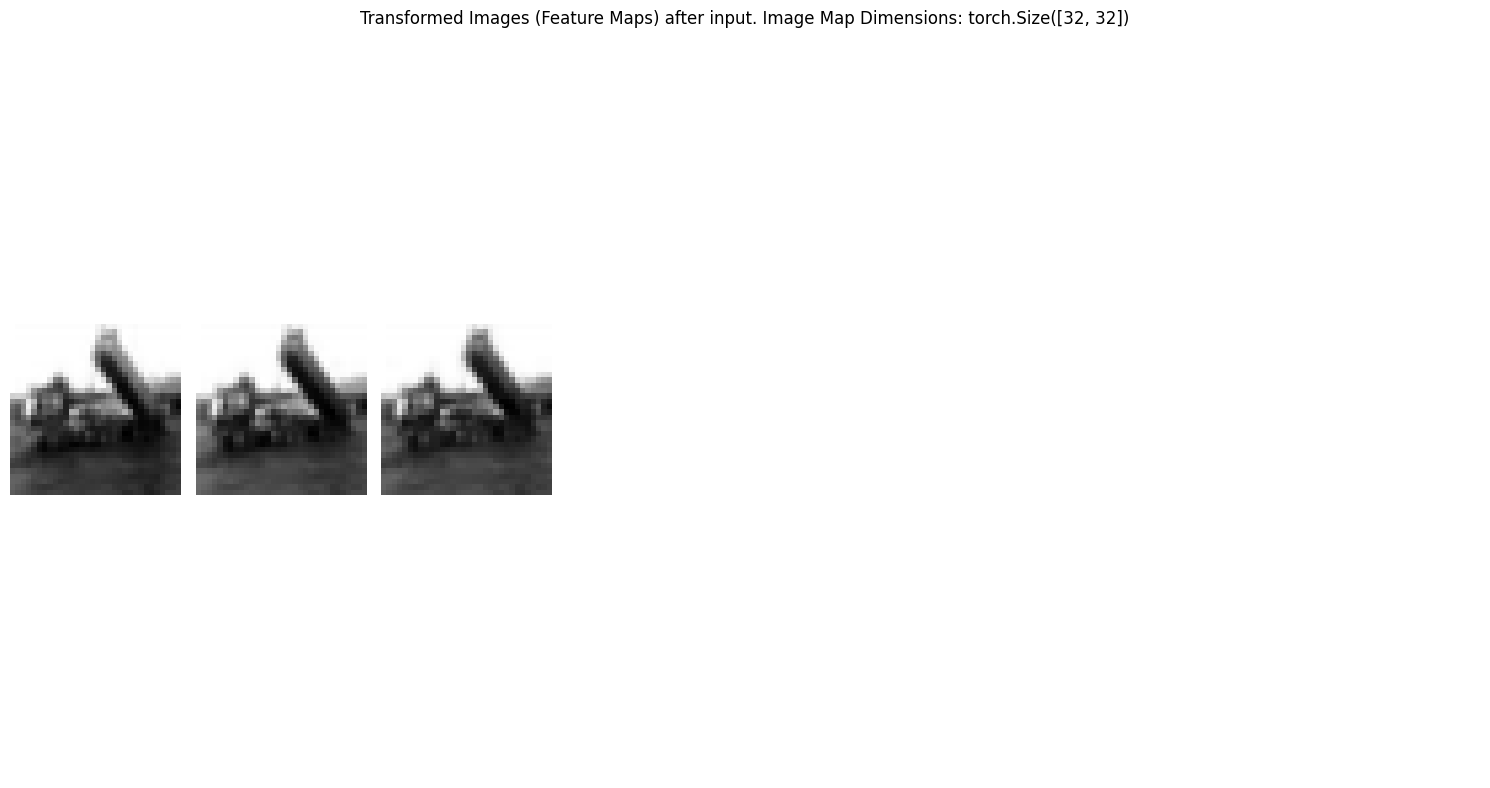

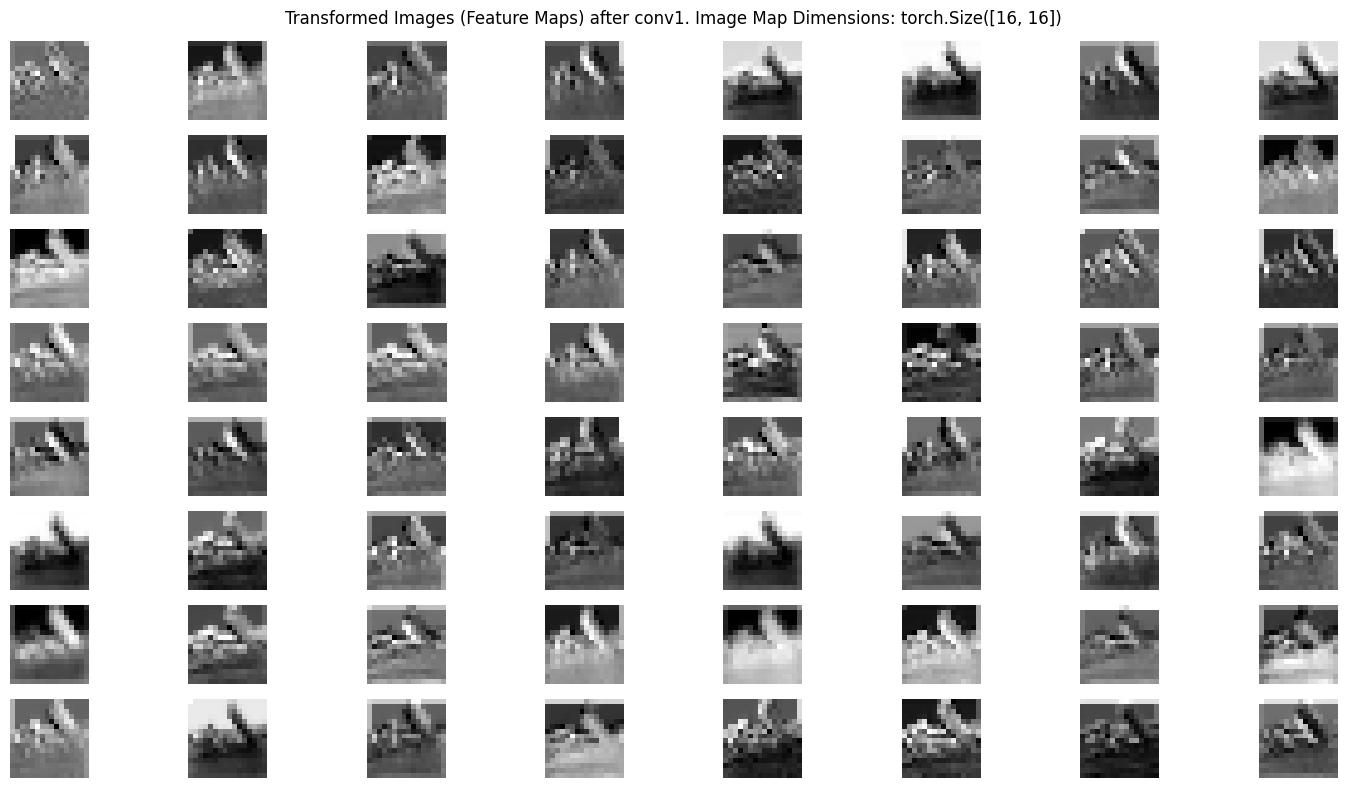

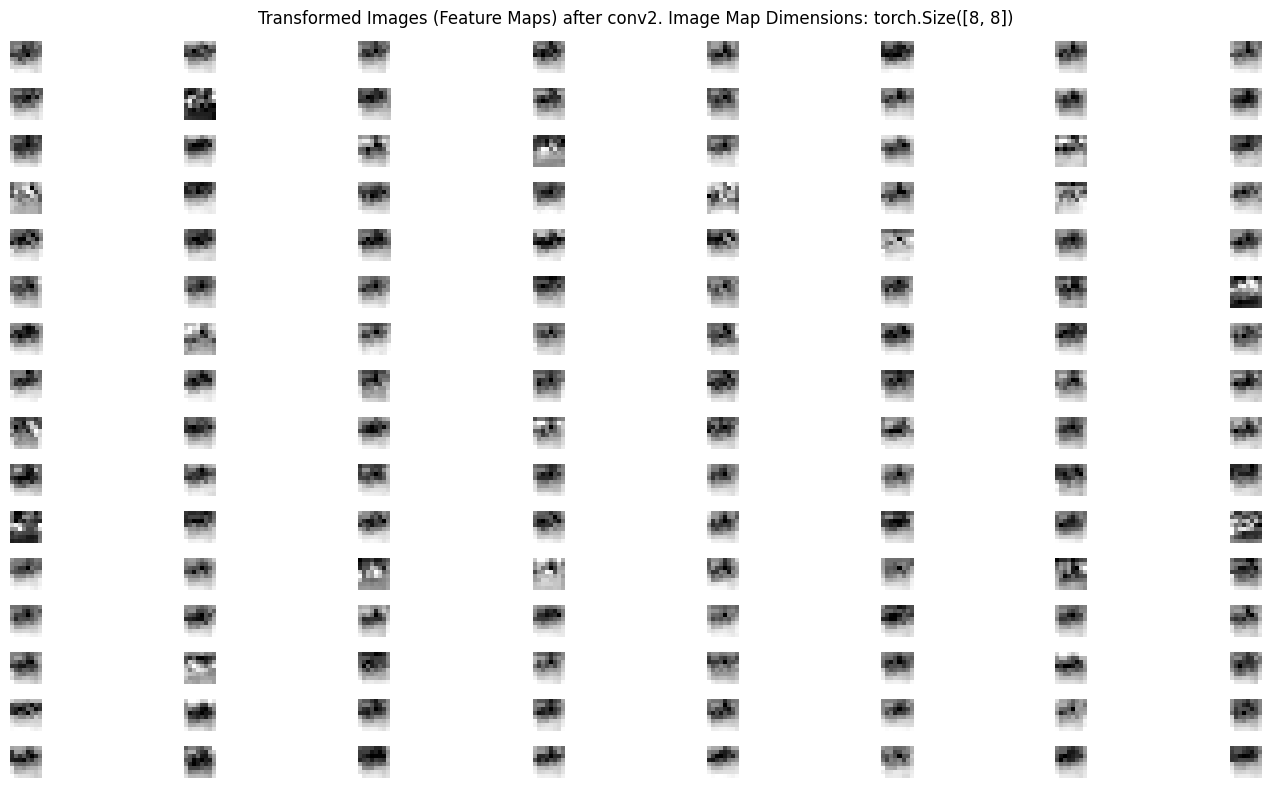

In [13]:
transformed_images = cnn_model.getTransformedImagesByLayer()

def DisplayTransformedImages(transformed_images, max_img_per_row=8):
    for layer_name, images in transformed_images.items():
        num_kernels = images.shape[0]
        num_rows = (num_kernels + max_img_per_row - 1) // max_img_per_row
        fig, axes = plt.subplots(num_rows, max_img_per_row, figsize=(15, 8))
        axes = axes.flatten()
        for i in range(num_kernels):
            img = images[i].cpu().detach().numpy()
            img = (img - img.min()) / (img.max() - img.min())  # Normalize to [0, 1]
            axes[i].imshow(img, cmap='gray')
            axes[i].axis('off')
            #axes[i].set_title(f'Kernel {i+1}')
        for i in range(num_kernels, len(axes)):
            axes[i].axis('off')
        plt.suptitle(f'Transformed Images (Feature Maps) after {layer_name}. Image Map Dimensions: {images.shape[1:]}')
        plt.tight_layout()
        plt.show()

DisplayTransformedImages(transformed_images, max_img_per_row=8)

#### Kernels

We can also visualize the kernels themselves in each of the convolutional layers. These filters will act to 'detect' certain features in the image, such as edges. Adding more kernels to a layer is the CNN equivalent to making fully connected layers wider - it allows the model to capture more features from the data.

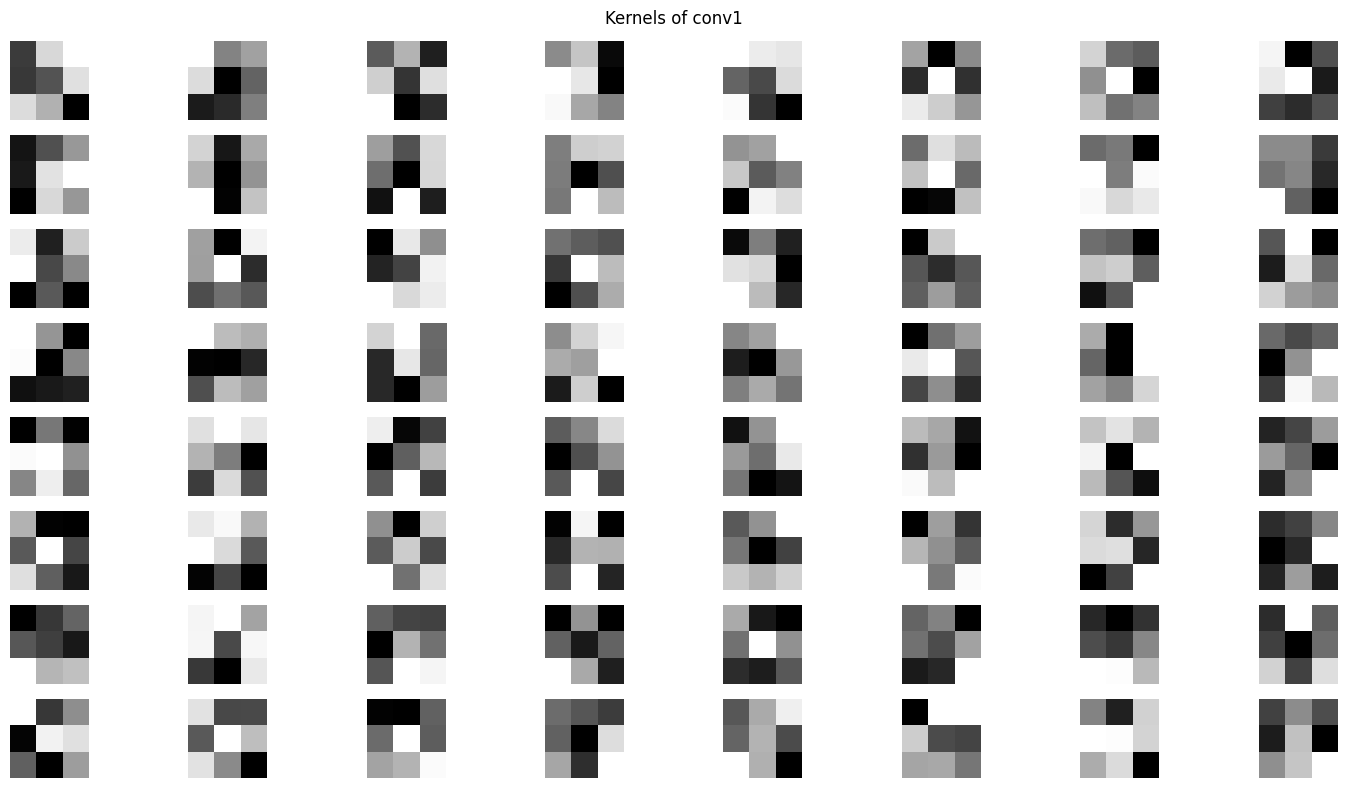

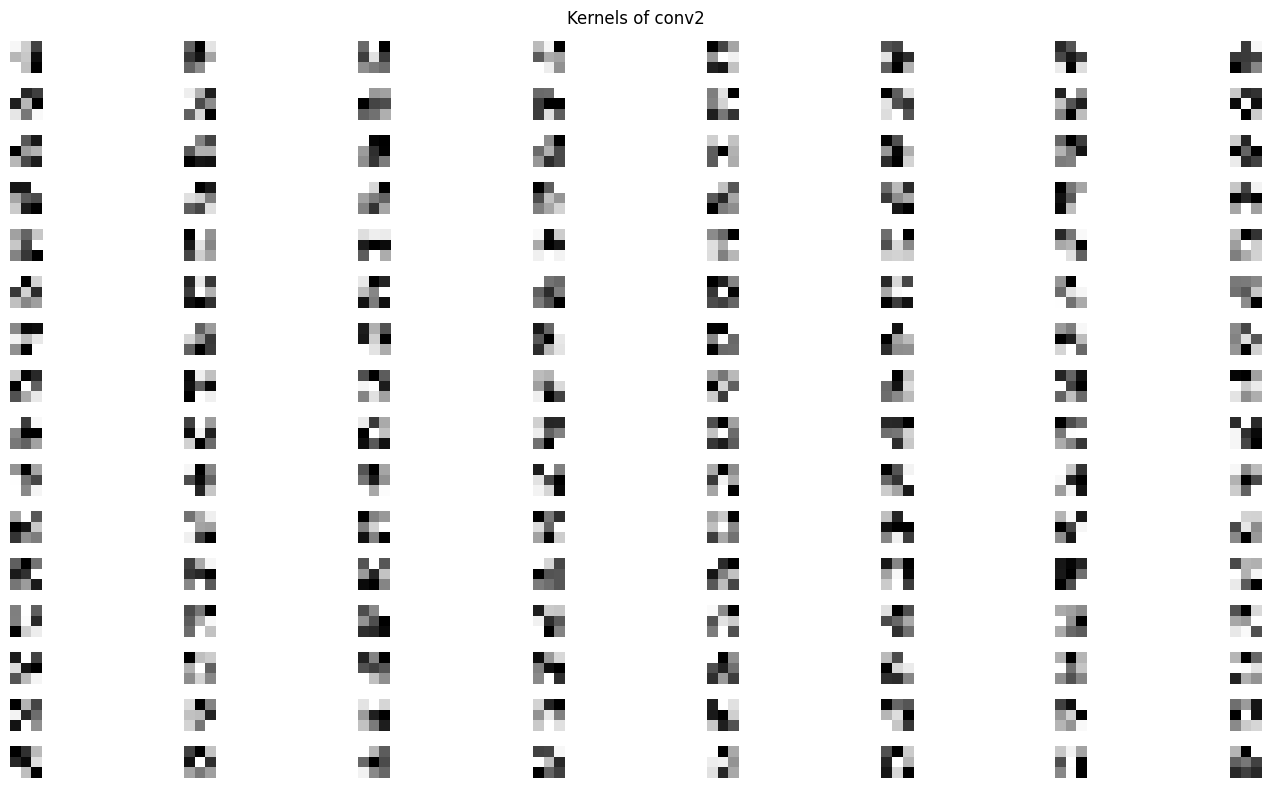

Example Kernel Tensor Shape:  torch.Size([3, 3, 3])
Example Kernel Tensor Values:  tensor([[[-0.1571,  0.0928,  0.1564],
         [-0.1621, -0.1191,  0.1067],
         [ 0.1004,  0.0315, -0.2519]],

        [[ 0.0658, -0.1388, -0.0052],
         [ 0.1650,  0.1292, -0.0623],
         [-0.0220,  0.0051, -0.0744]],

        [[-0.2359, -0.0063,  0.2158],
         [-0.0418, -0.1133,  0.1071],
         [ 0.2237,  0.1184, -0.1087]]], device='cuda:0')


In [14]:
import torchvision.utils as vutils

kernel_img = cnn_model.getConvLayerKernels()

def DisplayKernels(kernel_img, max_img_per_row=8):
    for layer in kernel_img:
        kernels = kernel_img[layer]
        num_kernels = kernels.shape[0]
        num_rows = (num_kernels + max_img_per_row - 1) // max_img_per_row
        fig, axes = plt.subplots(num_rows, max_img_per_row, figsize=(15, 8))
        axes = axes.flatten()
        for i in range(num_kernels):
            kernel = kernels[i].cpu().detach().numpy()
            kernel = (kernel - kernel.min()) / (kernel.max() - kernel.min())  # Normalize to [0, 1]
            img = kernel[0]
            #axes[i].imshow(img, cmap='gray' if kernel.shape[0] == 1 else None)
            axes[i].imshow(img, cmap='gray')
            axes[i].axis('off')
            #axes[i].set_title(f'Kernel {i+1}')
        for i in range(num_kernels, len(axes)):
            axes[i].axis('off')
        plt.suptitle(f'Kernels of {layer}')
        plt.tight_layout()
        plt.show()
DisplayKernels(kernel_img, max_img_per_row=8)

example_kernel_tensor = kernel_img['conv1'][0]
print("Example Kernel Tensor Shape: ", example_kernel_tensor.shape)
print("Example Kernel Tensor Values: ", example_kernel_tensor)

### Saliency Maps

Saliency maps are a way to visualize which parts of an image are most important for a model's prediction. They work by calculating the gradient of the output with respect to the input image, which gives us a measure of how much each pixel in the image is impacting the model's prediction. 

There are lots of other visualization libraries and examples out there that have prettier versions of these, but this does the job and is relatively simple to understand. This dataset doesn't offer the most dramatic saliency maps, since they are all pretty small and cropped portraits, the important pixels are overwhelmingly in the middle of most images. If we had a dataset with larger images and more space, these would be more interesting. 

In [15]:
class SaliencyMapViewer:
    def __init__(self, model, dataset, rows=2, cols=5, images=None, color_map="jet", image_alpha=0.4, sal_map_alpha=0.9):
        self.model = model
        self.dataset = dataset
        self.rows = rows
        self.cols = cols
        self.color_map = color_map
        self.image_alpha = image_alpha
        self.sal_map_alpha = sal_map_alpha
        
        total_needed = rows * cols
        if images is not None and len(images) >= total_needed:
            self.indices = list(images[:total_needed])
        elif images is not None:
            self.indices = list(images)
            remaining = total_needed - len(self.indices)
            all_indices = set(range(len(dataset))) - set(self.indices)
            self.indices += list(np.random.choice(list(all_indices), size=remaining, replace=False))
        else:
            self.indices = list(np.random.choice(len(dataset), size=total_needed, replace=False))
        
        self._build_widgets()
        self._render()
    
    def _build_widgets(self):
        available_cmaps = sorted(plt.colormaps())
        
        self.image_alpha_slider = widgets.FloatSlider(
            value=self.image_alpha, min=0.0, max=1.0, step=0.05,
            description='Image Alpha:', style={'description_width': 'initial'}, continuous_update=False
        )
        self.sal_alpha_slider = widgets.FloatSlider(
            value=self.sal_map_alpha, min=0.0, max=1.0, step=0.05,
            description='Saliency Alpha:', style={'description_width': 'initial'}, continuous_update=False
        )
        self.cmap_dropdown = widgets.Dropdown(
            options=available_cmaps, value=self.color_map,
            description='Colormap:', style={'description_width': 'initial'}
        )
        
        self.output = widgets.Output()
        
        self.image_alpha_slider.observe(self._on_change, names='value')
        self.sal_alpha_slider.observe(self._on_change, names='value')
        self.cmap_dropdown.observe(self._on_change, names='value')
        
        self._render()
        display(widgets.VBox([
            widgets.HBox([self.image_alpha_slider, self.sal_alpha_slider, self.cmap_dropdown]),
            self.output
        ]))
    
    def _on_change(self, change):
        self.image_alpha = self.image_alpha_slider.value
        self.sal_map_alpha = self.sal_alpha_slider.value
        self.color_map = self.cmap_dropdown.value
        self._render()
    
    def _render(self):
        self.output.clear_output(wait=True)
        with self.output:
            fig, axes = plt.subplots(self.rows, self.cols, figsize=(4 * self.cols, 4 * self.rows))
            if self.rows == 1 and self.cols == 1:
                axes = np.array([[axes]])
            elif self.rows == 1:
                axes = axes[np.newaxis, :]
            elif self.cols == 1:
                axes = axes[:, np.newaxis]
            
            for ax_idx, img_idx in enumerate(self.indices):
                row = ax_idx // self.cols
                col = ax_idx % self.cols
                
                sal = self.model.getSalienceMaps(sal_image=self.dataset[img_idx][0])
                sal_img = (sal - sal.min()) / (sal.max() - sal.min() + 1e-10)
                sal_img = sal_img.to('cpu').numpy()
                
                s_image = self.dataset[img_idx][0]
                s_image = (s_image - s_image.min()) / (s_image.max() - s_image.min() + 1e-10)
                
                axes[row, col].imshow(sal_img, cmap=self.color_map, alpha=self.sal_map_alpha)
                axes[row, col].imshow(s_image.permute(1, 2, 0).cpu().numpy(), alpha=self.image_alpha)
                axes[row, col].set_title(f'Class: {self.dataset.classes[self.dataset[img_idx][1]]} (idx={img_idx})')
                axes[row, col].axis('off')
            
            # Turn off any unused axes
            for ax_idx in range(len(self.indices), self.rows * self.cols):
                row = ax_idx // self.cols
                col = ax_idx % self.cols
                axes[row, col].axis('off')
            
            plt.tight_layout()
            plt.show()


In [16]:
viewer = SaliencyMapViewer(
    model=cnn_model,
    dataset=train_data,
    rows=4,
    cols=5,
)
viewer


### CNNs - Change Stride and Padding

#### Padding

Padding is used in convolutional layers to modify the dimensions of the feature maps by adding extra pixels around the borders of the input image. If our kernel size is larger than 1x1, applying the convolution operation will reduce the spatial dimensions of the input image. This reduction can lead to a loss of important information, especially for small images or images with fine details near the edges. Effectively, if there's no padding, the kernels are "limited" in their movement because they can't go beyond the borders of the image, which means that information along the edges. 

If padding is added, we add 1+ rows of a 'ring' of empty pixels around the image, which allows the kernels to move across the entire image and capture information from the edges as well. This can help improve the performance of the model by allowing it to learn from all parts of the image, not just the center.

Note that padding will also impact the size/quantity of features generated by the convolutional layers, and therefore the number of parameters in the model. This is because the output feature maps will have different dimensions based on whether padding is used or not, which in turn affects the number of connections to the fully connected layers. So, you can't just change padding without other adjustments, you'll need to make other changes to the structure to match the new dimensions of the feature maps.

#### Pooling

Pooling serves to reduce the spatial dimensions of the feature maps. 

In image classification this serves to reduce the number of parameters and combat overfitting. It makes the model able to generalize from data where the original details will differ widely. Less formally, the model will initially be able to 'detect' things in an image with the feature maps, then the pooling layers help generalize those things so that the model can recognize them in different contexts. This downsampling effectively simplifies several variations of the same feature down to a single representation, making it able to generalize better. 

##### Use the Pools

Pooling is very common, but it isn't strictly necessary and we can change the way we use it. At a high level, pooling reduces the dimensionality of the data, which we usually want with something like image classification. 

Image data generally starts with lots of dimensions, normally much more so than our small images we use for practice. The convolutional layers effectively generate a vector representation of the image in a lower number of dimensions. The convolution layers capture spatial relationships in the data that the model "uses" to make predictions - edges, shapes, etc... Pooling layers then reduce the dimensions of those representations, which helps to generalize from "this specific representation" to "this type of representation", so the model will represent a image of a cat as being very similar to other images of cats, even if the details are different.

##### Pooling Options

Pooling usually happens after a convolutional layer, but we can mix it up if we're feeling wild. For example, some more advanced models use different approaches. For example, some models use strided convolutions instead of pooling layers to reduce the spatial dimensions. This means that instead of applying a pooling operation after the convolutional layer, they use a convolutional layer with a stride greater than 1 to achieve the same effect of downsampling the feature maps. This can help to reduce the number of parameters and computational cost while still allowing the model to learn useful features from the images. We can also use pooling layers in a different order, for example, do two convolutional layers in a row, then do pooling, rather than doing convolution-pooling-convolution-pooling. This can allow the model to learn more complex features before reducing the dimensions, which can be beneficial for certain types of image data.

In this example here, the stride being larger and the lack of padding means that the convolutional layer will act to shrink the size of the outputs, just as pooling does. We need to make sure that we adapt the rest of the model to changes that may impact the dimensions, as everything downstream will be impacted. 

<b>Note:</b> there are lots of options here, too many to test yourself in any realistic scenario. If we want to make a good model, starting from what we know works is a better choice. 

In [17]:
class VaryingPoolStrideModel(nn.Module):
    def __init__(self, kernels1=32, kernels2=64):
        super(VaryingPoolStrideModel, self).__init__()
        stride = (2,2)
        padding = 0
        kern_size = (3,3)
        image_size = (32,32)
        self.conv1 = nn.Conv2d(in_channels=CHANNELS, out_channels=kernels1, kernel_size=kern_size, padding=padding, stride=stride)
        self.relu1 = nn.ReLU()
        # Current output size after conv1, with stride of 2: (32 - 3 + 2*0) / 2 + 1 = 15.5 -> 15 (floor)
        self.conv2 = nn.Conv2d(in_channels=kernels1, out_channels=kernels2, kernel_size=kern_size, padding=padding, stride=stride)
        self.relu2 = nn.ReLU()
        # Current output size after conv2, with stride of 2: (15 - 3 + 2*0) / 2 + 1 = 7.5 -> 7 (floor)
        self.pool2 = nn.MaxPool2d(kernel_size=(2,2))
        # Current output size after pool2, with stride of 2: 7 / 2 = 3.5 -> 3 (floor)
        self.flatten = nn.Flatten()
        # Each feature map is 3x3 (32x32 divided by 2, twice, with stride of 2), and there are 
        # kernels2 feature maps after the second conv layer, so kernels2*3*3 = kernels2*9
        self.fc1 = nn.Linear(kernels2 * 9, HIDDEN_UNITS)  # Adjust the input size based on your image dimensions
        self.fc2 = nn.Linear(HIDDEN_UNITS, OUTPUT_CLASSES)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

In [18]:
var_model = VaryingPoolStrideModel(kernels1=32, kernels2=64).to(device)
var_loss = nn.CrossEntropyLoss()
var_optimizer = torch.optim.Adam(var_model.parameters(), lr=LEARN_RATE)
summary(var_model, input_size=(CHANNELS, DIM_X, DIM_Y))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 15, 15]             896
              ReLU-2           [-1, 32, 15, 15]               0
            Conv2d-3             [-1, 64, 7, 7]          18,496
              ReLU-4             [-1, 64, 7, 7]               0
         MaxPool2d-5             [-1, 64, 3, 3]               0
           Flatten-6                  [-1, 576]               0
            Linear-7                  [-1, 512]         295,424
            Linear-8                   [-1, 10]           5,130
Total params: 319,946
Trainable params: 319,946
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.17
Params size (MB): 1.22
Estimated Total Size (MB): 1.40
----------------------------------------------------------------


In [19]:
# Train and evaluate the model
train_loop(train_loader, var_model, var_loss, var_optimizer, epochs=EPOCHS, val_dataloader=test_loader)
stride_full_res = multiDatasetTestRun(var_model, dataloaders=[test_loader, train_loader])

Epoch [1/12], Training Loss: 1.7850, Validation Loss: 1.5535, Val Accuracy: 44.64%
Epoch [2/12], Training Loss: 1.4570, Validation Loss: 1.4003, Val Accuracy: 50.05%
Epoch [3/12], Training Loss: 1.3336, Validation Loss: 1.3237, Val Accuracy: 52.96%
Epoch [4/12], Training Loss: 1.2503, Validation Loss: 1.2580, Val Accuracy: 55.17%
Epoch [5/12], Training Loss: 1.1865, Validation Loss: 1.2014, Val Accuracy: 57.18%
Epoch [6/12], Training Loss: 1.1375, Validation Loss: 1.1762, Val Accuracy: 58.35%
Epoch [7/12], Training Loss: 1.1075, Validation Loss: 1.1621, Val Accuracy: 58.72%
Epoch [8/12], Training Loss: 1.0680, Validation Loss: 1.1436, Val Accuracy: 60.13%
Epoch [9/12], Training Loss: 1.0458, Validation Loss: 1.1226, Val Accuracy: 60.74%
Epoch [10/12], Training Loss: 1.0230, Validation Loss: 1.1163, Val Accuracy: 61.28%
Epoch [11/12], Training Loss: 1.0126, Validation Loss: 1.1475, Val Accuracy: 59.21%
Epoch [12/12], Training Loss: 0.9828, Validation Loss: 1.0966, Val Accuracy: 62.02%


## How do 'Real' CNNs Work?

CNN models that perform very well tend to have more complex architectures than the one we built here, but the basic principles are the same. They have convolutional layers that extract features from the images, and fully connected layers that make predictions based on those features. The convolutional layers may be organized into blocks, with each block containing multiple convolutional layers followed by a pooling layer. The number of filters in the convolutional layers may increase as we go deeper into the network, allowing the model to capture more complex features. Additionally, modern CNNs often include techniques like batch normalization and dropout to improve training stability and reduce overfitting.

Image models tend to be very deep, with many layers. This allows CNN models to capture complex relationships in the data, as each CNN layer is basically presenting a new representation of the data. 

For best performance, mirroring some of the models that do well is a good start. On the other hand, these models tend to be complex, with a high capacity, and therefore need lots of data to be trained effectively. If the data we're using is smaller, which it almost certainly is, scaling things down is a good idea. 

![VGG 16](images/vgg16.png "VGG 16")

### Borrowing Another Model's Smarts

Each model we make here is specialized to the data we're using. In images, there tends to be some degree of commonality, even if dealing with totally different data. Detecting an edge is something that is likely pretty useful in doing all kinds of image recognition, it isn't something that's super specific to one application. If we combine this idea with the split of the CNN model into convolutional layers for feature extraction and fully connected layers for prediction, we can see that it might be possible to reuse the convolutional layers across different applications.

The convolutional layers in a CNN model serve to transform the raw pixel data into a set of features that are more useful for making predictions. The fully connected layers transform these features into a classification. The exact classification is always scenario specific, but the convolutional part is very similar from scenario to scenario. This means that we can reuse the convolutional layers from one model, that have been trained on a large dataset, and repurpose its ability to extract useful features to a different classification task. We can effectively swap out the fully connected layers that are targeted at the original problem, and attach ones that are targeted at our problem. The CNN parts will do the same thing, but we'll just use those features to make different predictions. This is called transfer learning, and it is a very common technique in deep learning, especially when working with image data. It allows us to leverage the knowledge learned from one task to improve performance on a different but related task, often with much less data than would be required to train a model from scratch. We can also enable some smaller scale training, or fine-tuning, to tweak the repurposed model to work better for our specific problem.

## Data Augmentation

When using images we can employ data augmentation to increase the size of our dataset, allowing for better training and resulting in better models. More data is king when it comes to model quality, so this is very helpful. 

The reason data augmentation is common and easy with images, where it isn't as straightforward with structured data is due to the nature of an image and what we are generally trying to do with it. Image problems are generally things like recognition - identifying what is in an image. If we are looking to identify if there is a cat in an image we probably don't  care if the cat is on the left side, the right side, rotated in any direction, tilted, etc... cats move in stupid and random ways, because they're insane lunatics, all we care about is if the cat is somewhere in there. 

![Augmented Cat](images/cat_aug.png "Augmented Cat" )

We can take advantage of this by doing all of those transformations to our images and using those transformed copies to augment our dataset! All of the mirrored, rotated, shifted, etc... images are just as good for the purposes of detecting a cat in an image, so we can use them. Free data!

In practice this is common and not really that difficult in most cases. As part of preparing the training data, we need to permute the images to rotate, zoom, shift, etc... to get a slightly different variation. We can expect a more generalizable model as if our goal is to spot cats, being able to spot them on the left, or on the right, or shifted, or rotated is an actual thing that we directly want our model to be able to do. 

Augmenting data and generating training data is something that is relatively common in many areas of machine learning - gathering and storing data can be expensive, so we want to make the most of what we have. The image examples are probably the most easy to understand, but the same idea applies to other types of data. The creation of training data is obviously something that is highly application dependent, and follows a simple idea that we've touched on a few times - as long as it helps the model predict what we need, it doesn't matter what the training data actually looks like. We've seen this in things like doing a log-transformation on income, or grouping infrequent categories into "other", the only goal is to help the model, and we can sometimes do that by distorting the data.

### Data Augmentation in PyTorch

In PyTorch, we can use the `torchvision.transforms` module to perform data augmentation on our image dataset. The `transforms` module provides a variety of transformations such as flips, rotation, cropping, etc... We can add these to the training data by adding multiple steps into the transform argument using a `transforms.Compose` function to assemble all the augmentation steps together.

Each augmentation step is normally a random change applied to the image - it rotates a bit, flips the image, shifts it left or right, etc... with each image generated. As the data is passed through training, each image is a slightly different version of the original, which will hopefully lead to a more generalizable model.

#### Non-Image Augmentation

Data augmentation isn't just for images, we can do it with other types of data as well. The general idea is the same - we want to create new training examples by applying some transformation to the existing data. The key is that the transformation should be something that doesn't change the underlying meaning of the data, but still provides a different perspective for the model to learn from.

Augmenting tabular data isn't quite as simple or intuitive as it is with images, but there are some scenarios. For example, if we have a dataset of customer transactions and profile information on loan applicant, we could add some noise to the data to create new examples. If we had a pattern where there are certain "levels" of income that are common, such as minimum wage or whatever a top of the grid teacher earns, we could add some random noise to those values to create new examples that are similar but not identical to the original data. This can help the model learn to generalize better and not overfit to the specific values in the training data. This is a domain knowledge heavy area, images are more straightforward. 

In [20]:
augmentation_dataset = datasets.CIFAR10('data',
                              train=True,
                              download=True,
                              transform=transforms.Compose([
                                  transforms.RandomHorizontalFlip(),
                                  transforms.RandomRotation(10),
                                  transforms.RandomRotation(10),
                                  transforms.ToTensor(),
                                  transforms.Normalize([0.485, 0.456, 0.406], [
                                      0.229, 0.224, 0.225
                                  ])
                              ])
                          )
augmentation_loader_train = DataLoader(augmentation_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [21]:
train_loop(augmentation_loader_train, cnn_model, cnn_loss, cnn_optimizer, epochs=EPOCHS, val_dataloader=test_loader)
cnn_full_res = multiDatasetTestRun(cnn_model, dataloaders=[test_loader, augmentation_loader_train])

Epoch [1/12], Training Loss: 1.1941, Validation Loss: 1.0168, Val Accuracy: 64.48%
Epoch [2/12], Training Loss: 1.0229, Validation Loss: 0.9769, Val Accuracy: 65.60%
Epoch [3/12], Training Loss: 0.9981, Validation Loss: 0.9494, Val Accuracy: 66.14%
Epoch [4/12], Training Loss: 0.9886, Validation Loss: 0.9248, Val Accuracy: 67.84%
Epoch [5/12], Training Loss: 0.9712, Validation Loss: 0.9388, Val Accuracy: 67.30%
Epoch [6/12], Training Loss: 0.9742, Validation Loss: 0.9475, Val Accuracy: 66.90%
Epoch [7/12], Training Loss: 0.9555, Validation Loss: 0.9509, Val Accuracy: 66.32%
Epoch [8/12], Training Loss: 0.9548, Validation Loss: 0.9229, Val Accuracy: 67.48%
Epoch [9/12], Training Loss: 0.9418, Validation Loss: 0.9148, Val Accuracy: 68.22%
Epoch [10/12], Training Loss: 0.9331, Validation Loss: 0.9072, Val Accuracy: 68.11%
Epoch [11/12], Training Loss: 0.9283, Validation Loss: 0.8963, Val Accuracy: 68.43%
Epoch [12/12], Training Loss: 0.9261, Validation Loss: 0.9107, Val Accuracy: 67.94%


## Exercise - Flower Time!

Use the flower dataset from the previous workbook and build a CNN model to classify the images. Play around with a few different architectures and such and see what the results are. 

### Complex Model Architecture

Just for fun, we can also try a model with a more complex architecture. This one is still relatively simple, the change is we split the convolutional layers into two separate paths - one with a 3x3 kernel, one with a 5x5 kernel. At the start of the fully connected layers, we concatenate the outputs of the two paths together, which is effectively like combining the numerical and categorical features together in a column transformer. Each path is learning to extract different features from the images, then the fully connected layers are able to use all of those features together to make predictions.

In some common models, we see many variations of this. For example, the ResNet set of models uses multiple paths in the convolutional layers. In theory, we could make almost any variation of structure imaginable, and they'd all work to some degree. If making something complex, we almost always want to start from something that is known to work, and then make adjustments from there.

#### Torch Math

When doing math with tensors, we need to make sure the tensors are both on the same device. We also need to ensure the shapes are compatible for the operation we're trying to do. For example, if we want to concatenate two tensors, they need to have the same number of dimensions and the same size in all dimensions except for the one we're concatenating on. We don't delve deep into tensor math, and we don't have many occasions to use it all that much. 

The operations are done using torch functions, such as `torch.cat` for concatenation. The documentation for PyTorch has a full list with the details on how to use each function, and the expected shapes and types of the inputs.

In [22]:
class ComplexCNN(nn.Module):
    def __init__(self, kernelsA1=64, kernelsA2=128, kernelsB1=64, kernelsB2=128, inchannels=3, hidden_units=512, output_classes=10):
        super(ComplexCNN, self).__init__()
        # Path A
        self.convA1 = nn.Conv2d(in_channels=inchannels, out_channels=kernelsA1, kernel_size=(3,3), padding=1)
        self.reluA1 = nn.ReLU()
        self.convA2 = nn.Conv2d(in_channels=kernelsA1, out_channels=kernelsA2, kernel_size=(3,3), padding=1)
        self.reluA2 = nn.ReLU()
        self.poolA = nn.MaxPool2d(kernel_size=(2,2))
        self.convA3 = nn.Conv2d(in_channels=kernelsA2, out_channels=kernelsA2, kernel_size=(3,3), padding=1)
        self.reluA3 = nn.ReLU()
        self.poolA2 = nn.MaxPool2d(kernel_size=(2,2))
        
        # Path B
        self.convB1 = nn.Conv2d(in_channels=inchannels, out_channels=kernelsB1, kernel_size=(5,5), padding=2)
        self.reluB1 = nn.ReLU()
        self.convB2 = nn.Conv2d(in_channels=kernelsB1, out_channels=kernelsB2, kernel_size=(5,5), padding=2)
        self.reluB2 = nn.ReLU()
        self.poolB = nn.MaxPool2d(kernel_size=(2,2))
        self.convB3 = nn.Conv2d(in_channels=kernelsB2, out_channels=kernelsB2, kernel_size=(5,5), padding=2)
        self.reluB3 = nn.ReLU()
        self.poolB2 = nn.MaxPool2d(kernel_size=(2,2))
        
        # Combined fully connected layers
        combined_features = (kernelsA2 * 8 * 8) + (kernelsB2 * 8 * 8)  # Assuming both paths reduce to 8x8 feature maps
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(combined_features, hidden_units)
        self.fc2 = nn.Linear(hidden_units, output_classes)

    def forward(self, x):
        # Path A
        xA = self.convA1(x)
        xA = self.reluA1(xA)
        xA = self.convA2(xA)
        xA = self.reluA2(xA)
        xA = self.poolA(xA)
        xA = self.convA3(xA)
        xA = self.reluA3(xA)
        xA = self.poolA2(xA)
        # Path B
        xB = self.convB1(x)
        xB = self.reluB1(xB)
        xB = self.convB2(xB)
        xB = self.reluB2(xB)
        xB = self.poolB(xB)
        xB = self.convB3(xB)
        xB = self.reluB3(xB)
        xB = self.poolB2(xB)

        # Combine paths
        combined = torch.cat((xA, xB), dim=1)  # Concatenate along the channel dimension
        combined = self.flatten(combined)
        combined = self.fc1(combined)
        output = self.fc2(combined)
        return output

In [23]:
complex_cnn_model = ComplexCNN(
    inchannels=CHANNELS,
    hidden_units=HIDDEN_UNITS,
    output_classes=OUTPUT_CLASSES
)

complex_cnn_model = complex_cnn_model.to(device)
complex_loss = nn.CrossEntropyLoss()
complex_optimizer = torch.optim.Adam(complex_cnn_model.parameters(), lr=LEARN_RATE)
summary(complex_cnn_model, input_size=(CHANNELS, DIM_X, DIM_Y))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
            Conv2d-3          [-1, 128, 32, 32]          73,856
              ReLU-4          [-1, 128, 32, 32]               0
         MaxPool2d-5          [-1, 128, 16, 16]               0
            Conv2d-6          [-1, 128, 16, 16]         147,584
              ReLU-7          [-1, 128, 16, 16]               0
         MaxPool2d-8            [-1, 128, 8, 8]               0
            Conv2d-9           [-1, 64, 32, 32]           4,864
             ReLU-10           [-1, 64, 32, 32]               0
           Conv2d-11          [-1, 128, 32, 32]         204,928
             ReLU-12          [-1, 128, 32, 32]               0
        MaxPool2d-13          [-1, 128, 16, 16]               0
           Conv2d-14          [-1, 128,

## Addendum - Visualizing Computation Graph

This isn't required, but we can also visualize the computation graph of our model. This is relevant mainly if you're doing work at one level lower than we are, creating custom calculations. The computation graph is a way to visualize the operations that are being performed in the model, and how the data flows through those operations. It can be helpful for understanding how the model is working, and for debugging purposes.

In [24]:
try:
    from torchviz import make_dot
except ImportError:
    !pip3 install torchviz
    from torchviz import make_dot

sample_image = train_data[SAMPLE_IMAGE_INDEX][0]
sample_image = sample_image.unsqueeze(0).to(device)  # Add batch dimension and move to device
dot_output = make_dot(complex_cnn_model(sample_image), params=dict(complex_cnn_model.named_parameters()))
dot_output.render("complex_cnn_model_graph", format="png")

'complex_cnn_model_graph.png'

In [25]:
train_loop(augmentation_loader_train, complex_cnn_model, complex_loss, complex_optimizer, epochs=EPOCHS, val_dataloader=test_loader)
complex_full_res = multiDatasetTestRun(complex_cnn_model, dataloaders=[test_loader, augmentation_loader_train])

Epoch [1/12], Training Loss: 1.9818, Validation Loss: 1.5611, Val Accuracy: 45.20%
Epoch [2/12], Training Loss: 1.4318, Validation Loss: 1.2991, Val Accuracy: 53.63%
Epoch [3/12], Training Loss: 1.2720, Validation Loss: 1.1917, Val Accuracy: 58.17%
Epoch [4/12], Training Loss: 1.1658, Validation Loss: 1.0924, Val Accuracy: 62.12%
Epoch [5/12], Training Loss: 1.0881, Validation Loss: 1.0142, Val Accuracy: 64.59%
Epoch [6/12], Training Loss: 1.0351, Validation Loss: 0.9765, Val Accuracy: 65.82%
Epoch [7/12], Training Loss: 0.9909, Validation Loss: 0.9184, Val Accuracy: 67.47%
Epoch [8/12], Training Loss: 0.9532, Validation Loss: 0.9076, Val Accuracy: 68.05%
Epoch [9/12], Training Loss: 0.9157, Validation Loss: 0.8763, Val Accuracy: 69.55%
Epoch [10/12], Training Loss: 0.8912, Validation Loss: 0.8444, Val Accuracy: 70.55%
Epoch [11/12], Training Loss: 0.8781, Validation Loss: 0.8411, Val Accuracy: 70.97%
Epoch [12/12], Training Loss: 0.8503, Validation Loss: 0.8382, Val Accuracy: 70.92%
